# Lattice ABP Steady-State MIPS Sanity Check

This notebook asks the two checks needed before training on lattice ABP data:

1. Does the exact-Gillespie simulation reach a usable late-time steady window?
2. In that window, does a macroscopic cluster remain stably present?

The diagnostics are intentionally scalar and conservative: block-mean stationarity, drift over the tail window, coarse density contrast, largest-cluster stability, and representative snapshots from the candidate training window.

In [49]:
import os
import sys
import time

candidate_roots = [
    os.environ.get("CNEEP_V2_ROOT"),
    os.path.abspath(".."),
    os.path.abspath("."),
    "/home/user1/CNEEP_v2",
]

CNEEP_V2_ROOT = None
for candidate in candidate_roots:
    if candidate and os.path.exists(os.path.join(candidate, "data", "lattice_abp", "core.py")):
        CNEEP_V2_ROOT = candidate
        break

if CNEEP_V2_ROOT is None:
    raise RuntimeError("Could not locate CNEEP_v2 root. Set CNEEP_V2_ROOT.")

if CNEEP_V2_ROOT not in sys.path:
    sys.path.append(CNEEP_V2_ROOT)

print("CNEEP_v2 root:", CNEEP_V2_ROOT)

CNEEP_v2 root: /home/ldh041203/projects/CNEEP_v2


In [50]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Patch
from IPython.display import Image, Video, display
from tqdm import tqdm

from data.lattice_abp.core import LatticeABP
from data.lattice_abp.mips_analysis import (
    coarse_density_periodic,
    summarize_mips_snapshot,
)

## 1. Configuration

In [51]:
device = "cuda" if torch.cuda.is_available() else "cpu"

abp_params = dict(
    L=64,
    v_plus=10.0,
    v_zero=1,
    v_minus=1,
    D_rot=0.1,
    density=0.55,
    bc_mode="periodic",
    device=device,
    seed=123,
)

# Use a small exact-Gillespie ensemble.  Increase B or n_snapshots when a
# publication-quality stationarity check is needed.
B = 10
burn_in_events = 1000_000
n_snapshots = 1000
steps_per_snapshot = 200
coarse_box = 8

# Candidate learning window: the final tail_fraction of saved snapshots.
tail_fraction = 0.40
stationarity_rel_tol = 0.10
stationarity_drift_sigma_tol = 0.45

# Stable macroscopic-cluster criteria inside the candidate steady window.
cluster_fraction_threshold = 0.35
cluster_dropout_tol = 0.05
cluster_cv_tol = 0.30

output_dir = os.path.join(CNEEP_V2_ROOT, "results", "sanity_lattice_abp_steady_mips")
os.makedirs(output_dir, exist_ok=True)

Pe = (abp_params["v_plus"] - abp_params["v_minus"]) / (2 * abp_params["D_rot"])
print(f"Device: {device}")
print(f"Output: {output_dir}")
print(f"L={abp_params['L']}, density={abp_params['density']}, Pe={Pe:.2f}, B={B}")
print(f"Burn-in exact Gillespie events per ensemble: {burn_in_events:,}")
print(f"Recorded exact Gillespie events per ensemble: {n_snapshots * steps_per_snapshot:,}")

Device: cuda
Output: /home/ldh041203/projects/CNEEP_v2/results/sanity_lattice_abp_steady_mips
L=64, density=0.55, Pe=45.00, B=10
Burn-in exact Gillespie events per ensemble: 1,000,000
Recorded exact Gillespie events per ensemble: 200,000


## 2. Run Exact Gillespie Simulation

In [52]:
sim = LatticeABP(**abp_params)
O, E = sim.init_state(B=B)

frames_occ = []
frames_jammed = []
times = []
summaries = []
jammed_fraction = []

sim_time = np.zeros(B, dtype=np.float64)
N = int(abp_params["density"] * abp_params["L"] ** 2)

def record_snapshot():
    jammed = sim.compute_jammed_mask(O, E)
    frames_occ.append(O[0].detach().cpu().numpy().copy())
    frames_jammed.append(jammed[0].detach().cpu().numpy().copy())
    times.append(sim_time.copy())

    per_ensemble = []
    jf = []
    for b in range(B):
        occ_np = O[b].detach().cpu().numpy().copy()
        n_jammed = int((jammed[b] & (O[b] == 1)).sum().item())
        jf.append(n_jammed / max(N, 1))
        per_ensemble.append(
            summarize_mips_snapshot(
                occ_np,
                density=abp_params["density"],
                coarse_box=coarse_box,
                periodic=True,
            )
        )

    summaries.append(per_ensemble)
    jammed_fraction.append(jf)

print(f"Burn-in ({burn_in_events:,} exact Gillespie events per ensemble)...")
t0 = time.time()
burn_in_time = np.zeros(B, dtype=np.float64)
with torch.inference_mode():
    for _ in tqdm(range(burn_in_events), desc="Burn-in"):
        O, E, dt_vec = sim.gillespie_step(O, E)
        burn_in_time += dt_vec.detach().cpu().numpy()

burn_elapsed = time.time() - t0
print(f"Burn-in done in {burn_elapsed:.1f}s")
print(f"Mean burn-in Gillespie time: {burn_in_time.mean():.4f}")

# Record production time relative to the post-burn-in state.
sim_time[:] = 0.0
record_snapshot()

print("Running exact Gillespie events...")
t0 = time.time()
with torch.inference_mode():
    for snap in tqdm(range(1, n_snapshots + 1)):
        for _ in range(steps_per_snapshot):
            O, E, dt_vec = sim.gillespie_step(O, E)
            sim_time += dt_vec.detach().cpu().numpy()
        record_snapshot()

elapsed = time.time() - t0
print(f"Done in {elapsed:.1f}s")
print(f"Saved snapshots: {len(frames_occ)}")
print(f"Final mean Gillespie time: {np.mean(times[-1]):.4f}")

Burn-in (1,000,000 exact Gillespie events per ensemble)...


Burn-in: 100%|██████████████████████████████████████████████████████████████| 1000000/1000000 [22:29<00:00, 741.22it/s]


Burn-in done in 1349.1s
Mean burn-in Gillespie time: 231.3297
Running exact Gillespie events...


100%|██████████████████████████████████████████████████████████████████████████████| 1000/1000 [04:51<00:00,  3.43it/s]

Done in 291.7s
Saved snapshots: 1001
Final mean Gillespie time: 53.1737


## 3. Build Observable Time Series

In [53]:
metric_names = [
    "density",
    "largest_cluster_fraction",
    "coarse_std_ratio",
    "coarse_q10",
    "coarse_q90",
    "low_k_ratio",
]

n_saved = len(summaries)
metrics = {}
for name in metric_names:
    metrics[name] = np.array([[summaries[t][b][name] for b in range(B)] for t in range(n_saved)])

metrics["jammed_fraction"] = np.asarray(jammed_fraction)
metrics["coarse_contrast"] = metrics["coarse_q90"] - metrics["coarse_q10"]
times_arr = np.asarray(times)
time_axis = times_arr.mean(axis=1)

tail_start = int(np.floor((1.0 - tail_fraction) * n_saved))
tail_start = max(1, min(tail_start, n_saved - 2))
tail_slice = slice(tail_start, None)
tail_time = time_axis[tail_slice]

print(f"Saved snapshots: {n_saved}")
print(f"Candidate steady window starts at snapshot {tail_start}/{n_saved - 1}")
print(f"Candidate steady window starts at mean Gillespie time {time_axis[tail_start]:.4f}")
print(f"Tail snapshots: {n_saved - tail_start}")

Saved snapshots: 1001
Candidate steady window starts at snapshot 600/1000
Candidate steady window starts at mean Gillespie time 31.9209
Tail snapshots: 401


## 4. Stationarity Checks for Learning

In [54]:
def stationarity_report(values, time, tail_start, rel_tol=0.10, drift_sigma_tol=0.45):
    values = np.asarray(values, dtype=float)
    if values.ndim == 1:
        values = values[:, None]

    tail = values[tail_start:]
    time_tail = np.asarray(time[tail_start:], dtype=float)
    mid = max(1, len(tail) // 2)

    first = tail[:mid].mean(axis=0)
    second = tail[mid:].mean(axis=0)
    tail_mean_per_ensemble = tail.mean(axis=0)
    tail_mean = float(tail.mean())
    tail_std = float(tail.std(ddof=1)) if tail.size > 1 else 0.0

    rel_shift_per_ensemble = np.abs(second - first) / (np.abs(tail_mean_per_ensemble) + 1e-12)
    rel_shift = float(np.mean(rel_shift_per_ensemble))
    max_rel_shift = float(np.max(rel_shift_per_ensemble))

    ensemble_mean_series = tail.mean(axis=1)
    if len(time_tail) >= 2 and np.ptp(time_tail) > 0:
        slope = float(np.polyfit(time_tail, ensemble_mean_series, deg=1)[0])
        drift_span = abs(slope) * float(time_tail[-1] - time_tail[0])
    else:
        slope = 0.0
        drift_span = 0.0
    drift_sigma = float(drift_span / (tail_std + 1e-12))
    cv = float(tail_std / (abs(tail_mean) + 1e-12))

    ok = bool(rel_shift <= rel_tol and drift_sigma <= drift_sigma_tol)
    return {
        "tail_mean": tail_mean,
        "tail_std": tail_std,
        "tail_cv": cv,
        "rel_shift": rel_shift,
        "max_rel_shift": max_rel_shift,
        "slope": slope,
        "drift_sigma": drift_sigma,
        "ok": ok,
    }


stationarity_metrics = [
    "density",
    "largest_cluster_fraction",
    "coarse_std_ratio",
    "coarse_contrast",
    "jammed_fraction",
]

stationarity = {
    name: stationarity_report(
        metrics[name],
        time_axis,
        tail_start,
        rel_tol=stationarity_rel_tol,
        drift_sigma_tol=stationarity_drift_sigma_tol,
    )
    for name in stationarity_metrics
}

print("Stationarity over candidate learning window")
print(f"  rel_shift tolerance:     {stationarity_rel_tol}")
print(f"  drift_sigma tolerance:   {stationarity_drift_sigma_tol}")
print()
print(f"{'observable':28s} {'mean':>11s} {'cv':>9s} {'rel_shift':>11s} {'drift_sig':>11s} {'pass':>6s}")
for name, rep in stationarity.items():
    print(
        f"{name:28s} {rep['tail_mean']:11.5f} {rep['tail_cv']:9.3f} "
        f"{rep['rel_shift']:11.3f} {rep['drift_sigma']:11.3f} "
        f"{'yes' if rep['ok'] else 'no':>6s}"
    )

steady_state_ok = all(rep["ok"] for rep in stationarity.values())
print()
print("Candidate learning window is stationary:", "YES" if steady_state_ok else "NO")

Stationarity over candidate learning window
  rel_shift tolerance:     0.1
  drift_sigma tolerance:   0.45

observable                          mean        cv   rel_shift   drift_sig   pass
density                          0.54980     0.000       0.000       0.000    yes
largest_cluster_fraction         0.92735     0.010       0.007       0.371    yes
coarse_std_ratio                 5.71383     0.027       0.016       0.581     no
coarse_contrast                  0.88410     0.021       0.014       0.460     no
jammed_fraction                  0.90727     0.009       0.004       0.260    yes

Candidate learning window is stationary: NO


## 5. Stable Large-Cluster Check

In [55]:
cluster_tail = metrics["largest_cluster_fraction"][tail_slice]
cluster_mean = float(cluster_tail.mean())
cluster_std = float(cluster_tail.std(ddof=1)) if cluster_tail.size > 1 else 0.0
cluster_cv = cluster_std / (cluster_mean + 1e-12)
cluster_q05 = float(np.quantile(cluster_tail, 0.05))
cluster_q10 = float(np.quantile(cluster_tail, 0.10))
cluster_min = float(cluster_tail.min())
cluster_dropout = float(np.mean(cluster_tail < cluster_fraction_threshold))

coarse_tail = metrics["coarse_contrast"][tail_slice]
coarse_contrast_mean = float(coarse_tail.mean())
coarse_contrast_q10 = float(np.quantile(coarse_tail, 0.10))

large_cluster_ok = bool(
    cluster_mean >= cluster_fraction_threshold
    and cluster_q10 >= 0.90 * cluster_fraction_threshold
    and cluster_dropout <= cluster_dropout_tol
    and cluster_cv <= cluster_cv_tol
)

print("Stable large-cluster summary over candidate learning window")
print(f"  mean largest-cluster fraction: {cluster_mean:.4f}")
print(f"  std largest-cluster fraction:  {cluster_std:.4f}")
print(f"  CV:                            {cluster_cv:.4f}")
print(f"  q05 / q10 / min:               {cluster_q05:.4f} / {cluster_q10:.4f} / {cluster_min:.4f}")
print(f"  dropout below {cluster_fraction_threshold:.2f}:          {100 * cluster_dropout:.2f}%")
print(f"  coarse contrast mean/q10:       {coarse_contrast_mean:.4f} / {coarse_contrast_q10:.4f}")
print()
print("Large cluster is stable:", "YES" if large_cluster_ok else "NO")

Stable large-cluster summary over candidate learning window
  mean largest-cluster fraction: 0.9274
  std largest-cluster fraction:  0.0091
  CV:                            0.0098
  q05 / q10 / min:               0.9121 / 0.9152 / 0.8956
  dropout below 0.35:          0.00%
  coarse contrast mean/q10:       0.8841 / 0.8594

Large cluster is stable: YES


## 6. Time Series With Candidate Window

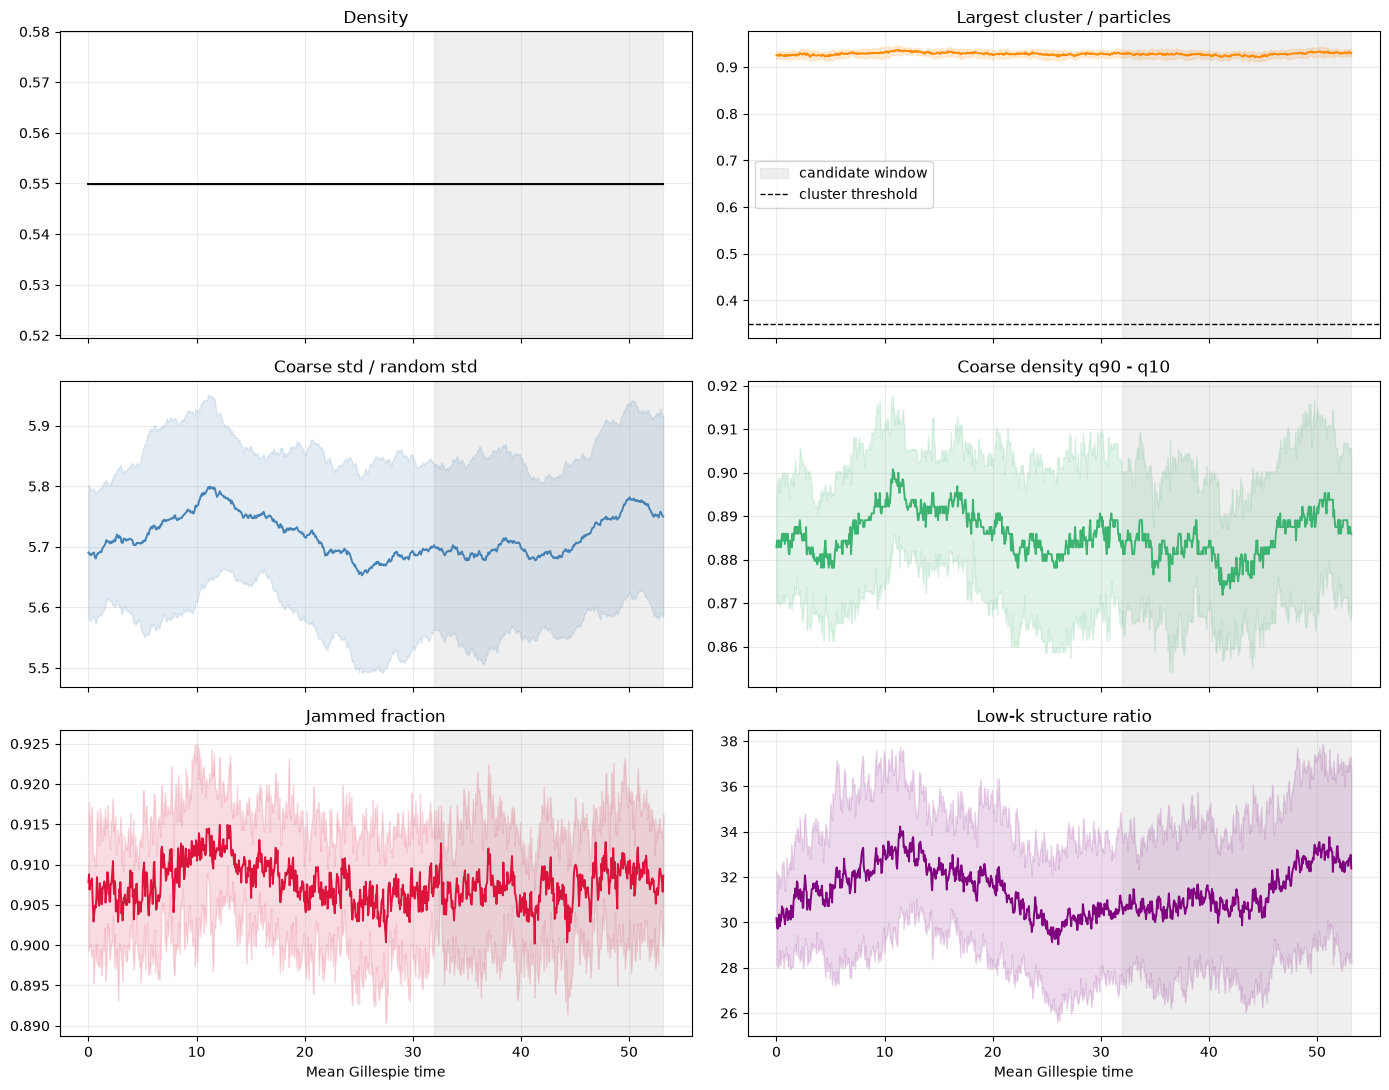

In [56]:
fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=True)
axes = axes.ravel()

plot_specs = [
    ("density", "Density", "black"),
    ("largest_cluster_fraction", "Largest cluster / particles", "darkorange"),
    ("coarse_std_ratio", "Coarse std / random std", "steelblue"),
    ("coarse_contrast", "Coarse density q90 - q10", "mediumseagreen"),
    ("jammed_fraction", "Jammed fraction", "crimson"),
    ("low_k_ratio", "Low-k structure ratio", "purple"),
]

for ax, (name, title, color) in zip(axes, plot_specs):
    vals = metrics[name]
    mean = vals.mean(axis=1)
    std = vals.std(axis=1)
    ax.plot(time_axis, mean, color=color, lw=1.4)
    ax.fill_between(time_axis, mean - std, mean + std, color=color, alpha=0.15)
    ax.axvspan(time_axis[tail_start], time_axis[-1], color="gray", alpha=0.12, label="candidate window")
    ax.set_title(title)
    ax.grid(alpha=0.25)

axes[1].axhline(cluster_fraction_threshold, color="black", ls="--", lw=1, label="cluster threshold")
axes[-1].set_xlabel("Mean Gillespie time")
axes[-2].set_xlabel("Mean Gillespie time")

handles, labels = axes[1].get_legend_handles_labels()
if handles:
    axes[1].legend(loc="best")

plt.tight_layout()
plt.savefig(f"{output_dir}/steady_window_time_series.png", dpi=150)
plt.show()

## 7. Snapshots From the Candidate Training Window

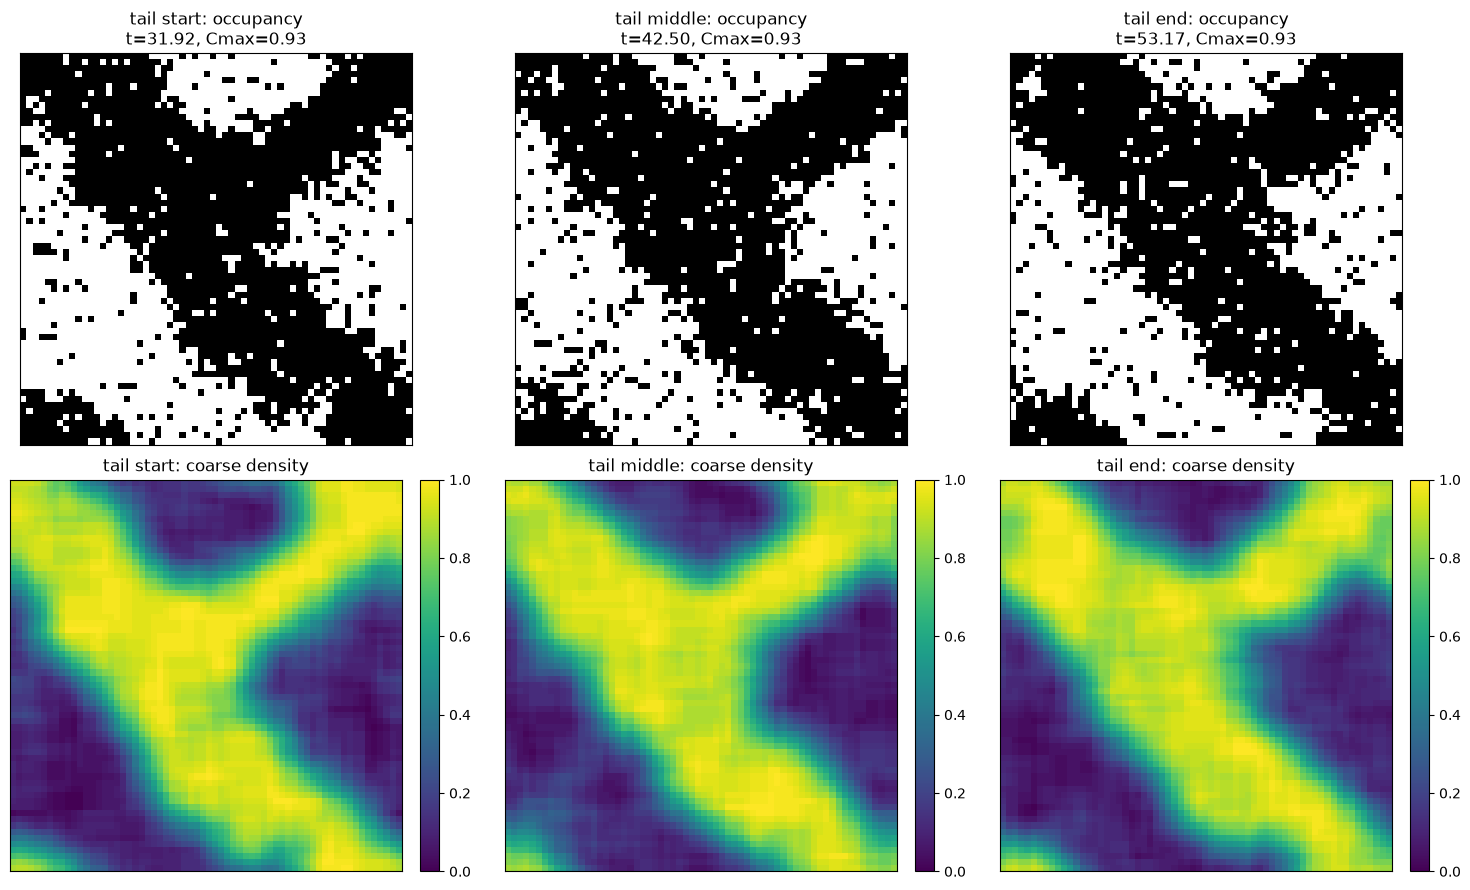

In [57]:
tail_indices = [tail_start, tail_start + (n_saved - tail_start) // 2, n_saved - 1]
labels = ["tail start", "tail middle", "tail end"]

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for col, (idx, label) in enumerate(zip(tail_indices, labels)):
    occ = frames_occ[idx]
    coarse = coarse_density_periodic(occ, box=coarse_box)

    im0 = axes[0, col].imshow(occ.T, origin="lower", cmap="Greys", vmin=0, vmax=1)
    axes[0, col].set_title(
        f"{label}: occupancy\nt={time_axis[idx]:.2f}, "
        f"Cmax={metrics['largest_cluster_fraction'][idx].mean():.2f}"
    )
    axes[0, col].set_xticks([])
    axes[0, col].set_yticks([])

    im1 = axes[1, col].imshow(coarse.T, origin="lower", cmap="viridis", vmin=0, vmax=1)
    axes[1, col].set_title(f"{label}: coarse density")
    axes[1, col].set_xticks([])
    axes[1, col].set_yticks([])
    fig.colorbar(im1, ax=axes[1, col], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig(f"{output_dir}/candidate_window_snapshots.png", dpi=150)
plt.show()

## 8. Save Sanity Video

In [61]:
def build_video_rgb(occ, jam):
    rgb = np.zeros((occ.shape[0], occ.shape[1], 3), dtype=np.float32)
    rgb[:, :, 0] = 0.07
    rgb[:, :, 1] = 0.08
    rgb[:, :, 2] = 0.10

    free = (occ == 1) & (~jam)
    blocked = (occ == 1) & jam
    rgb[free] = (0.20, 0.60, 0.86)
    rgb[blocked] = (0.91, 0.30, 0.24)
    return rgb


video_max_frames = 300
video_stride = max(1, int(np.ceil(len(frames_occ) / video_max_frames)))
video_indices = np.arange(0, len(frames_occ), video_stride, dtype=int)
if video_indices[-1] != len(frames_occ) - 1:
    video_indices = np.append(video_indices, len(frames_occ) - 1)

fps = 20
video_path = os.path.join(output_dir, "lattice_abp_steady_mips_sanity.mp4")
gif_path = os.path.join(output_dir, "lattice_abp_steady_mips_sanity.gif")

fig, ax = plt.subplots(figsize=(6, 6), facecolor="#0d1117")
ax.set_facecolor("#0d1117")
ax.set_xticks([])
ax.set_yticks([])
ax.set_aspect("equal")

first_idx = int(video_indices[0])
im = ax.imshow(
    build_video_rgb(frames_occ[first_idx], frames_jammed[first_idx]),
    interpolation="nearest",
)
title = ax.set_title("", color="white", fontsize=11, fontweight="bold", pad=10)
info_text = ax.text(
    0.02,
    0.02,
    "",
    transform=ax.transAxes,
    color="white",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="#111827", edgecolor="#444", alpha=0.85),
    verticalalignment="bottom",
)
ax.legend(
    handles=[
        Patch(facecolor="#3498db", label="occupied"),
        Patch(facecolor="#e74c3c", label="jammed"),
    ],
    loc="upper right",
    fontsize=9,
    facecolor="#111827",
    edgecolor="#444",
    labelcolor="white",
)


def update_video(frame_number):
    idx = int(video_indices[frame_number])
    im.set_data(build_video_rgb(frames_occ[idx], frames_jammed[idx]))
    title.set_text(
        f"Lattice ABP sanity | snapshot {idx}/{n_saved - 1} | "
        f"t={time_axis[idx]:.2f}"
    )
    info_text.set_text(
        f"Cmax={metrics['largest_cluster_fraction'][idx].mean():.3f}\n"
        f"jammed={metrics['jammed_fraction'][idx].mean():.3f}\n"
        f"tail starts at {tail_start}"
    )
    return [im, title, info_text]


anim = animation.FuncAnimation(
    fig,
    update_video,
    frames=len(video_indices),
    interval=1000 // fps,
    blit=False,
)

import matplotlib as mpl

try:
    import imageio_ffmpeg

    ffmpeg_path = imageio_ffmpeg.get_ffmpeg_exe()
    mpl.rcParams["animation.ffmpeg_path"] = ffmpeg_path
    print("Using ffmpeg:", ffmpeg_path)

    writer = animation.FFMpegWriter(fps=fps, bitrate=2400)
    anim.save(
        video_path,
        writer=writer,
        dpi=120,
        savefig_kwargs={"facecolor": fig.get_facecolor()},
    )
    saved_video_path = video_path
    plt.close(fig)
    print(f"Saved video: {saved_video_path}")
    display(Video(saved_video_path, embed=True, width=600))

except Exception as exc:
    print(f"MP4 save failed ({type(exc).__name__}: {exc})")
    print("Saving GIF fallback instead.")

    writer = animation.PillowWriter(fps=fps)
    anim.save(
        gif_path,
        writer=writer,
        dpi=100,
        savefig_kwargs={"facecolor": fig.get_facecolor()},
    )
    saved_video_path = gif_path
    plt.close(fig)
    print(f"Saved GIF: {saved_video_path}")
    display(Image(filename=saved_video_path))

Using ffmpeg: /home/ldh041203/.conda/envs/jupyter-gpu/lib/python3.12/site-packages/imageio_ffmpeg/binaries/ffmpeg-linux-x86_64-v7.0.2
Saved video: /home/ldh041203/projects/CNEEP_v2/results/sanity_lattice_abp_steady_mips/lattice_abp_steady_mips_sanity.mp4


## 9. Tail Distributions

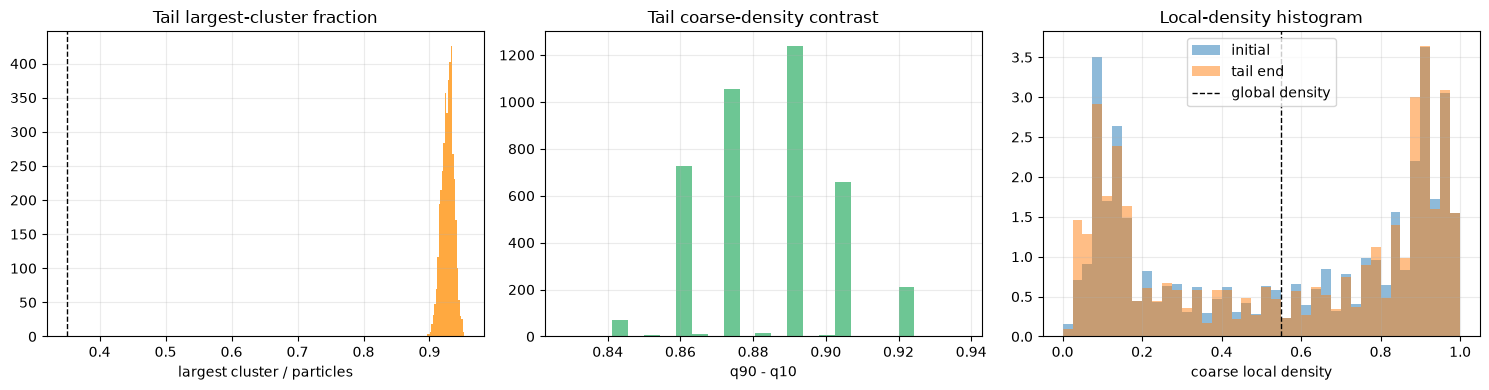

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cluster_tail.ravel(), bins=25, alpha=0.75, color="darkorange")
axes[0].axvline(cluster_fraction_threshold, color="black", ls="--", lw=1)
axes[0].set_title("Tail largest-cluster fraction")
axes[0].set_xlabel("largest cluster / particles")

axes[1].hist(coarse_tail.ravel(), bins=25, alpha=0.75, color="mediumseagreen")
axes[1].set_title("Tail coarse-density contrast")
axes[1].set_xlabel("q90 - q10")

initial_coarse = coarse_density_periodic(frames_occ[0], box=coarse_box).ravel()
tail_end_coarse = coarse_density_periodic(frames_occ[-1], box=coarse_box).ravel()
bins = np.linspace(0, 1, 41)
axes[2].hist(initial_coarse, bins=bins, alpha=0.50, density=True, label="initial")
axes[2].hist(tail_end_coarse, bins=bins, alpha=0.50, density=True, label="tail end")
axes[2].axvline(abp_params["density"], color="black", ls="--", lw=1, label="global density")
axes[2].set_title("Local-density histogram")
axes[2].set_xlabel("coarse local density")
axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.savefig(f"{output_dir}/tail_distributions.png", dpi=150)
plt.show()

## 10. Final Verdict and Training Recommendation

In [60]:
criteria = {
    "candidate steady window exists": steady_state_ok,
    "large cluster stable in window": large_cluster_ok,
    "largest cluster mean above threshold": cluster_mean >= cluster_fraction_threshold,
    "largest cluster dropout acceptable": cluster_dropout <= cluster_dropout_tol,
}

for name, ok in criteria.items():
    print(f"{name:40s}: {'PASS' if ok else 'NO'}")

print()
if steady_state_ok and large_cluster_ok:
    print("PASS: use the candidate tail window for learning.")
    extra_discard_events = tail_start * steps_per_snapshot
    total_discard_events = burn_in_events + extra_discard_events
    print(f"Explicit burn-in already applied: {burn_in_events:,} events per ensemble.")
    print(f"Additional production discard before tail: {extra_discard_events:,} events per ensemble.")
    print(f"Recommended total discard: {total_discard_events:,} events per ensemble.")
    print(f"Recommended production snapshot start: {tail_start}.")
    print(f"Recommended post-burn-in production time: {time_axis[tail_start]:.4f}.")
    print(f"Mean explicit burn-in Gillespie time: {burn_in_time.mean():.4f}.")
else:
    print("BORDERLINE / FAIL: do not use this run as-is for learning.")
    print("Try increasing burn_in_events, n_snapshots, steps_per_snapshot, or B.")
    print("If stationarity fails with cluster fraction still drifting upward, the system is still coarsening.")

candidate steady window exists          : NO
large cluster stable in window          : PASS
largest cluster mean above threshold    : PASS
largest cluster dropout acceptable      : PASS

BORDERLINE / FAIL: do not use this run as-is for learning.
Try increasing burn_in_events, n_snapshots, steps_per_snapshot, or B.
If stationarity fails with cluster fraction still drifting upward, the system is still coarsening.
